# Section: Determining a Velocity Model For Utopia Planitita

This notebook shows how we derive velocity model from the preprocessed Utopia Planitia gpr data. Manual annotations done twice, c3 and auto hyperbola fit done once. I omit any explainations or walkthrough of these methods as they're covered previously in the paper and under different sections. This notebook should just be applying the mothods and getting data.

# Import our in-house package and dependencies
Should install relevant dependencies if there is a conflict

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from pds4_tools.reader.core import pds4_read
from tqdm import tqdm

sys.path.append('../..')

import RoPeR
from RoPeR import bandpass, bgr, energy_eq, gain, prestitch
import SimulatingGPR.gprsim as gprsim

/Users/coltenrodriguez/anaconda3/lib/python3.10/site-packages/bruges/__init__.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


## Need to check out the data to get reelvant constants, but we can ompit all the preprocessing

In [2]:
'''
Retrieving files and sorting them
'''
n, m = 0, 109 # 0-109, load all 109 files
data_dir = '/Users/coltenrodriguez/Desktop/Senior_Thesis/RoPeR_LF' # were data

In [3]:
files = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if '.2CL' in f]
files = sorted(files, key=lambda f: int(f[-10:-6]))[n:m]
length = len(files)

sample_depth = {6000:15000, 4000:10000, 2000:5000, 1000:2500} # number of total pixels in either R/I data: nanoseconds penetration
observable_depth_ns = 1200 # Arbitaraty value

In [4]:
from collections import Counter, defaultdict
'''
Check inhomogenous data (e.g. not all files are LF). also get the effective data legnth (to get ns/px)
'''

effective_data_lens = [info[8] for info in [pds4_read(file, quiet=True)[0].data[0] for file in files]] # Just take the metadata associated with the first trace, as each trace in each file will be the same


if len(set(effective_data_lens)) == 1:
    print(f"Input data is homogenous. Effective data length is {effective_data_lens[0]} bytes. \n {effective_data_lens[0]/8} fpn for real data -- {(effective_data_lens[0]/8)/sample_depth[effective_data_lens[0]/8]} px/ns")
    half_length = int(effective_data_lens[0]/8)
    px_per_ns = half_length/sample_depth[effective_data_lens[0]/8]
else:
    print("Inhomogenous data types. Check that all files are LF or have the same effective data length")

Input data is homogenous. Effective data length is 48000 bytes. 
 6000.0 fpn for real data -- 0.4 px/ns


In [5]:
remove_air = 0
'''
Stitching multiple data files together and gathering some preprocessing data for each file
'''
phase = [0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
pixel_distances = []
sample_meta = None
for f, i, j in zip(files, range(0, length), tqdm(range(length-1))): 
    if n<=i<=m:
        fdata = pds4_read(f, quiet=True)[0].data
        if len(set([int.from_bytes(d[6], 'big', signed=False) for d in fdata])) > 1:
            raise Exception("Trigger mode is not homogenously fixed_distance")
        sample_meta = fdata[0] # might be useless
        scan2d = np.array([d[9] for d in fdata])
        real_part_scan2d = np.array(scan2d[:, :half_length]).T[remove_air:, :]
        
        sample_depth_px, real_part_scan2d_depth_adj = prestitch.depth_correction(real_part_scan2d, px_per_ns, observable_depth_ns)
        real_part_scan2d_depth_self_adj, sds = prestitch.remove_self_detection(real_part_scan2d_depth_adj)
        sds = prestitch.phase_correction(sds, phase[i])
        real_part_scan2d_depth_self_phase_adj = prestitch.phase_correction(real_part_scan2d_depth_self_adj, phase[i])
        real_part_scan2d_depth_self_phase_bgr_adj, _ = bgr.remove_bg(real_part_scan2d_depth_self_phase_adj)
        # Assume this is all interpreted
        yaw = np.array([d[23] for d in fdata])
        pos_x = np.array([d[19] for d in fdata])
        pos_y = np.array([d[20] for d in fdata])
        pos_z = np.array([d[21] for d in fdata])
        pixel_distances.append(np.array([int.from_bytes(d[7], 'big', signed=False) for d in fdata])*10e-3)
        if i == n:
            raw = real_part_scan2d_depth_adj
            self_detection = real_part_scan2d_depth_self_adj
            phase_offset = real_part_scan2d_depth_self_phase_adj
            phase_offset_bg = real_part_scan2d_depth_self_phase_bgr_adj
            self_detections = np.array(sds)
            yaws = yaw
            poss_x, poss_y, poss_z = pos_x, pos_y, pos_z
            trace_dist_m = np.sum(np.array([int.from_bytes(d[7], 'big', signed=False) for d in fdata])*10e-3) # Fixed dist trigger is not fixed for all scans, record dist in a way that pulls from the .CL
        else:
            raw = np.concatenate((raw, real_part_scan2d_depth_adj), axis=1)
            self_detection = np.concatenate((self_detection, real_part_scan2d_depth_self_adj), axis=1)
            phase_offset = np.concatenate((phase_offset, real_part_scan2d_depth_self_phase_adj), axis=1)
            phase_offset_bg = np.concatenate((phase_offset_bg, real_part_scan2d_depth_self_phase_bgr_adj), axis=1)
            self_detections = np.concatenate((self_detections, sds), axis=1)
            yaws = np.concatenate((yaws, yaw))
            poss_x, poss_y, poss_z = np.concatenate((poss_x, pos_x)), np.concatenate((poss_y, pos_y)), np.concatenate((poss_z, pos_z))
            trace_dist_m+=np.sum(np.array([int.from_bytes(d[7], 'big', signed=False) for d in fdata])*10e-3)
            

100%|███████████████████████████████████████████████████████████████| 107/107 [00:14<00:00,  7.27it/s]


In [25]:
# load the preprocessed data
p = np.load('/Users/coltenrodriguez/Desktop/GPR-modeling/Sections/determining_a_velocity_model/preprocessed_data.npy')


# Generate a velocity model for the subsurface

We have preprocessed the data and it was so easy! (it wasnt). Now we can finally begin doing what is literally everyone else's first step in GPR processing!

Li et. al. go to 1200ns. I personally have a hard time trusting data at 171m. Even for dry sand and gravel at such low frequency, everyone I've talked to wouldn't expect >100m. Even the IDed dipping reflectors weren't bellow 20m. I think we strike a good balance restricting ourselves to the upper 80m, which, for the absolute lowest eps_r, should be around 800-1000ns.

In [7]:
def meters_to_pixels(meter_interval, pixel_distances):
    start_m, end_m = meter_interval

    # cumulative distance to the start of each pixel
    cumulative_m = np.concatenate(([0], np.cumsum(pixel_distances)))

    # find pixel indices
    start_pixel = np.searchsorted(cumulative_m, start_m, side="left")
    end_pixel = np.searchsorted(cumulative_m, end_m, side="right") - 1

    # clamp to valid range
    start_pixel = max(0, min(start_pixel, len(pixel_distances) - 1))
    end_pixel = max(0, min(end_pixel, len(pixel_distances) - 1))

    return start_pixel, end_pixel
    
def norm2d(array):
    min_val = np.min(array)
    max_val = np.max(array)
    
    # Apply the normalization formula
    normalized_array = 2 * ((array - min_val) / (max_val - min_val)) - 1
    
    return normalized_array

def zoom(array, bounds):
    # Bounds in [left, right, bottom, top]
    # [:, :], Col slice (vertical), rows slice (horiz), row slice should be left:right, byut col slice should be bottom:top
    '''
    Bounds should be specified as:

                Left: Left coordinate (in meters)
                Right: Right coord (in meters)
                Top: stratigraphic bottom, the larger twt (in ns)
                Bottom: stratigraphic top, the smaller twt (in ns)

    This way bounds may be passed as an arg to plt without modification to show true (phyiscal) position 
    '''
    left, right = meters_to_pixels((bounds[0], bounds[1]), np.concatenate(pixel_distances).ravel())
    return array[int(bounds[3]*0.4):int(bounds[2]*0.4), left:right], bounds
    

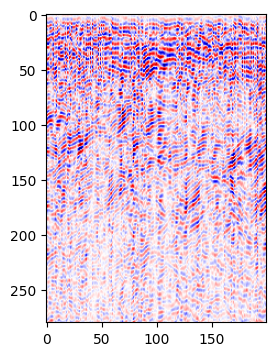

In [8]:
min_x, max_x = 0, 100
min_t, max_t = 0, 700
array, bounds = zoom(p, [min_x, max_x, max_t, min_t])
cmap = plt.get_cmap('seismic')
rgb_img = cmap(array)[:,:,0]
fig = plt.figure(figsize=(6,4))
plt.imshow(array, cmap="seismic")

## 5.2 Hyperbola fitting, more options
1. manually anotate to get hyperbolae -- This easy and pretty reliable, but I've always said, why do something the easy way when you can spend 2 months learning and coding a worse solution? -->
2. C3!! This is the **preeminent** hyperbola anotating algorithm. Unfortuantely, in most cases, our data is so noisy (in ways that we couldn't remove using standard -- not overkill -- signal processing) that this doesn't work. I'll use a combination of both. The hyperbola are subtle in this data, not nearly as perfect as the contrived examples in the c3 paper so this is expected.

### 5.2.1 User Discretion -- Classic Manual Hyperbola Drawing

In [69]:
import numpy as np

def hyperbola_t(x, v, x0, t0):
    return np.sqrt(t0**2 + (2*(x - x0)/v)**2)

def goodness_of_fit(t_obs, t_pred):
    resid = t_obs - t_pred
    rmse = np.sqrt(np.mean(resid**2))
    mae = np.mean(np.abs(resid))
    ss_res = np.sum(resid**2)
    ss_tot = np.sum((t_obs - np.mean(t_obs))**2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return {"rmse": rmse, "mae": mae, "r2": r2, "residuals": resid}

def hyperbola(x, y):
    xs =  np.array(x)/2
    x = (xs*dx) + min_x # Convert to native coords in m
    
    ys =  np.array(y)/2
    t = (ys*(1/px_per_ns)) + min_t # Convert to native coords in t
    
    A = np.column_stack([x**2, -2*x, 1.0*np.ones_like(x)])
    b = t**2
    
    consts = np.linalg.pinv(A) @ b
    r = A @ consts - b
    sigma = 1.5 * np.median(np.abs(r - np.median(r)))
    
    mask = np.abs(r) <= 0.5 * sigma
    consts2 = np.linalg.pinv(A[mask]) @ b[mask]
    alpha, beta, gamma = consts2
    
    if alpha <= 0:
        print('None')
    
    v = np.sqrt(1/alpha)
    x0 = beta * v**2
    inside = gamma - (x0**2 / v**2)
    
    if inside <= 0:
        print('None')
        
    t0 = np.sqrt(inside)
    
    # ---- goodness of fit ----
    t_pred = hyperbola_t(x, v, x0, t0)
    gof = goodness_of_fit(t, t_pred)
    eps_r = np.sqrt(0.3/v)

    t_pred = hyperbola_t(x, v, x0, t0)
    gof = goodness_of_fit(t, t_pred)

    return eps_r, x0, t0, gof

In [158]:
import tkinter as tk
import numpy as np
from PIL import Image, ImageTk

hyperbolae = {'coords': [], 'perms': []}

def fit_hyperbola(xs_px, ys_px, dx, dt, resize_factor, bounds):
    """
    Fit a hyperbola to three (x, y) points in pixel space and extract permittivity.

    A GPR diffraction hyperbola follows:
        t(x)^2 = t0^2 + (x - x0)^2 / v^2
    where t is two-way travel time, x is horizontal position,
    t0 is the apex travel time, x0 is the apex position, and v is the wave velocity.

    Rearranging: t^2 = (1/v^2) * x^2 - (2*x0/v^2) * x + (t0^2 + x0^2/v^2)
    This is linear in [x^2, x, 1], so we solve with least squares.

    Parameters
    ----------
    xs_px : array-like, pixel x coordinates of the three clicked points
    ys_px : array-like, pixel y coordinates of the three clicked points
    dx : float, meters per pixel in x (after resize)
    dt : float, nanoseconds per pixel in y (after resize)
    resize_factor : float, factor by which image was resized
    bounds : tuple, (left, right) pixel indices of the slice in the larger image

    Returns
    -------
    eps_r : float, estimated relative permittivity
    x0_m : float, apex x position in meters (in the larger image frame)
    t0_ns : float, apex two-way travel time in nanoseconds
    """
    c = 0.3  # speed of light in m/ns

    # Convert pixel coords to physical units
    xs_m = np.array(xs_px, dtype=float) * dx
    ys_ns = np.array(ys_px, dtype=float) * dt

    # We fit: t^2 = A*x^2 + B*x + C  (linear least squares)
    # where A = 1/v^2, B = -2*x0/v^2, C = t0^2 + x0^2/v^2
    t_sq = ys_ns ** 2
    X = np.column_stack([xs_m ** 2, xs_m, np.ones(len(xs_m))])
    coeffs, _, _, _ = np.linalg.lstsq(X, t_sq, rcond=None)
    A, B, C = coeffs

    if A <= 0:
        print("Warning: non-physical hyperbola fit (A <= 0). Try different points.")
        return None, None, None

    v = 1.0 / np.sqrt(A)           # m/ns
    x0_m = -B / (2 * A)            # apex x in local (slice) meters
    t0_sq = C - (B ** 2) / (4 * A)

    if t0_sq < 0:
        print("Warning: non-physical hyperbola fit (t0^2 < 0). Try different points.")
        return None, None, None

    t0_ns = np.sqrt(t0_sq)         # apex two-way travel time in ns

    eps_r = (c / v) ** 2           # relative permittivity

    # Convert apex x back to the larger image frame in meters
    x0_global_px = x0_m / dx + bounds[0] / resize_factor
    x0_global_m = x0_global_px * dx

    return eps_r, x0_global_m, t0_ns


class HyperbolaDrawer:
    def __init__(self, root, image_array, dx, dt, bounds, resize_factor=2):
        """
        Parameters
        ----------
        root : tk.Tk root window
        image_array : 2D numpy array, the radargram slice (pre-resized)
        dx : float, meters per original pixel horizontally
        dt : float, nanoseconds per original pixel vertically
        bounds : tuple, (left_px, right_px) of the slice in the larger image
        resize_factor : int, how much the image has been upscaled for display
        """
        self.root = root
        self.dx = dx / resize_factor      # adjusted for resize
        self.dt = dt / resize_factor      # adjusted for resize
        self.bounds = bounds
        self.resize_factor = resize_factor

        # Normalize and convert to 8-bit for display
        arr = image_array.astype(float)
        arr -= arr.min()
        if arr.max() > 0:
            arr /= arr.max()
        arr = (arr * 255).astype(np.uint8)

        self.img = Image.fromarray(arr)
        self.tk_img = ImageTk.PhotoImage(self.img)

        self.canvas = tk.Canvas(root, width=self.img.width, height=self.img.height)
        self.canvas.pack()
        self.canvas.create_image(0, 0, anchor='nw', image=self.tk_img)

        # Instructions label
        self.label = tk.Label(root, text="Click 3 points on a hyperbola. Repeat for more.")
        self.label.pack()

        self.points = []
        self.canvas.bind("<Button-1>", self.on_click)

    def on_click(self, event):
        x, y = event.x, event.y
        print(x, y)
        self.points.append((x, y))
        r = 3
        self.canvas.create_oval(x - r, y - r, x + r, y + r,
                                fill='red', outline='red')

        if len(self.points) == 3:
            self.fit_and_draw_hyperbola()

    def fit_and_draw_hyperbola(self):
        xs_px = [p[0] for p in self.points]
        ys_px = [p[1] for p in self.points]

        eps_r, x0_m, t0_ns = fit_hyperbola(
            xs_px, ys_px, self.dx, self.dt, self.resize_factor, self.bounds
        )

        if eps_r is None:
            self.points = []
            return

        # Draw the fitted hyperbola overlay in pixel space
        # t(x)^2 = t0^2 + (x - x0_local)^2 / v^2
        c = 0.3  # m/ns
        v = c / np.sqrt(eps_r)
        x0_local_px = (x0_m - self.bounds[0] * self.dx) / self.dx
        t0_px = t0_ns / self.dt

        x_range = np.linspace(0, self.img.width - 1, 1000)
        x_m = x_range * self.dx
        x0_local_m = x0_local_px * self.dx
        t_sq = t0_ns ** 2 + (x_m - x0_local_m) ** 2 / v ** 2
        t_sq = np.maximum(t_sq, 0)
        y_range = np.sqrt(t_sq) / self.dt

        # Draw line segments, clipping to canvas
        for i in range(len(x_range) - 1):
            x1, y1 = x_range[i], y_range[i]
            x2, y2 = x_range[i + 1], y_range[i + 1]
            if (0 <= y1 < self.img.height and 0 <= y2 < self.img.height):
                self.canvas.create_line(x1, y1, x2, y2, fill='cyan', width=2)

        # Mark the apex
        apex_x_px = x0_local_px
        apex_y_px = t0_px
        r = 5
        self.canvas.create_oval(
            apex_x_px - r, apex_y_px - r,
            apex_x_px + r, apex_y_px + r,
            outline='yellow', width=2
        )

        # Store and report results
        hyperbolae['coords'].append((x0_m, t0_ns))
        hyperbolae['perms'].append(eps_r)
        print(f"eps_r = {eps_r:.3f} | apex x = {x0_m:.2f} m | apex t = {t0_ns:.2f} ns")

        self.points = []  # reset for next hyperbola


if __name__ == "__main__":
    import cv2

    # --- Replace these with your actual data ---
    dx = 0.5       # meters per pixel, horizontal
    dt = 1/2.5        # nanoseconds per pixel, vertical
    bounds = (0, 500)   # left and right pixel indices in the larger image
    resize_factor = 2
    # -------------------------------------------

    depth, width = array.shape
    resized = cv2.resize(array, (width * resize_factor, depth * resize_factor),
                         interpolation=cv2.INTER_LINEAR)

    root = tk.Tk()
    root.title("Hyperbola Permittivity Picker")
    app = HyperbolaDrawer(root, resized, dx, dt, bounds, resize_factor)
    root.mainloop()

    print("\nAll results:")
    for coord, perm in zip(hyperbolae['coords'], hyperbolae['perms']):
        print(f"  eps_r = {perm:.3f} | apex = {coord}")


182 115
197 96
212 105
eps_r = 29.090 | apex x = 49.96 m | apex t = 119.32 ns

All results:
  eps_r = 29.090 | apex = (49.95900653145413, 119.32107666519579)


In [427]:
"""
GPR Hyperbola Picker
====================
Estimate dielectric permittivity by fitting hyperbolae to hand-picked
points on a radargram.

Physics
-------
Clicks are immediately converted to physical units (metres, nanoseconds).
One-way travel time t_one = t_twoway / 2 is used throughout the fit so
the hyperbola equation is in its canonical form:

    t_one² = t0² + (x - x0)² / v²

Permittivity is recovered as  εr = (c / v)²

The fit uses scipy.optimize.least_squares on the squared residual form,
which is numerically better conditioned than fitting t directly.

Usage
-----
    results = run_picker(radargram, dx, dt, bounds)

Parameters
----------
radargram : 2-D numpy array  (rows = time, cols = distance)
dx        : float — metres per pixel  (horizontal)
dt        : float — nanoseconds per pixel  (vertical)
bounds    : (min_t_ns, max_t_ns, min_x_m, max_x_m)
            physical extent of this slice; used both to label axes and
            to convert pixel clicks to absolute physical coordinates.

Returns
-------
results : list of dicts, one per fitted hyperbola:
    {
        'permittivity'  : float,   # εr
        'velocity_m_ns' : float,   # v  (m/ns)
        'apex_x_m'      : float,   # x0 in metres (absolute)
        'apex_t_ns'     : float,   # t0 two-way travel time (ns)
        'depth_m'       : float,   # one-way depth  v * t0 / 2  ... wait,
                                   # t0 here IS already one-way, so depth = v * t0
        'residual_norm' : float,
    }
"""

import tkinter as tk
from tkinter import ttk
import numpy as np
from scipy.optimize import least_squares
import matplotlib
matplotlib.use("TkAgg")
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import matplotlib.pyplot as plt
import matplotlib.lines

C_M_PER_NS = 0.299792458   # speed of light (m/ns)


# ---------------------------------------------------------------------------
# Physics
# ---------------------------------------------------------------------------

def fit_hyperbola(points_m_ns):
    """
    Fit a point-reflector hyperbola to physical-unit (x_m, t_twoway_ns) points.

    Internally works in one-way time:  t_one = t_twoway / 2
    Residual:  r = t_one² - (t0² + (x - x0)² / v²)

    Parameters
    ----------
    points_m_ns : array-like, shape (N, 2)  columns: [x_m, t_twoway_ns]

    Returns
    -------
    x0   : float  apex x position (m)
    t0   : float  apex one-way travel time (ns)
    v    : float  wave velocity (m/ns)
    er   : float  relative permittivity
    res  : OptimizeResult from least_squares
    """
    pts  = np.array(points_m_ns)
    x    = pts[:, 0]
    t    = pts[:, 1] / 2.0          # one-way travel time

    x0_g = x[np.argmin(t)]
    t0_g = np.min(t)
    v_g  = 0.1                      # m/ns  →  εr ≈ 9

    def residuals(params):
        x0, t0, v = params
        return t**2 - (t0**2 + (x - x0)**2 / v**2)

    lo = [x.min() - 5.0,  max(t.min() * 0.5, 1e-3),  0.03]
    hi = [x.max() + 5.0,  t.max() * 2.0,              C_M_PER_NS]

    res = least_squares(residuals, [x0_g, t0_g, v_g], bounds=(lo, hi))
    x0, t0, v = res.x
    er = (C_M_PER_NS / v) ** 2
    return x0, t0, v, er, res


def hyperbola_curve(x_m_range, x0_m, t0_one_ns, v_m_ns):
    """
    Return two-way travel time (ns) for a point-reflector hyperbola.
    x_m_range : array of x positions in metres
    """
    t_one = np.sqrt(t0_one_ns**2 + (x_m_range - x0_m)**2 / v_m_ns**2)
    return t_one * 2.0              # back to two-way


# ---------------------------------------------------------------------------
# Application
# ---------------------------------------------------------------------------

class HyperbolaPicker:
    POINT_RADIUS = 4
    COLORS = ["#e63946", "#2a9d8f", "#e9c46a", "#f4a261", "#a8dadc",
              "#c77dff", "#80b918", "#f77f00"]

    def __init__(self, root, radargram, dx, dt, bounds):
        """
        Parameters
        ----------
        dx     : metres per pixel
        dt     : nanoseconds per pixel
        bounds : (min_t_ns, max_t_ns, min_x_m, max_x_m)
        """
        self.root      = root
        self.radargram = radargram
        self.dx        = dx          # m / px
        self.dt        = dt          # ns / px
        self.min_t     = bounds[0]   # ns
        self.max_t     = bounds[1]   # ns
        self.min_x     = bounds[2]   # m
        self.max_x     = bounds[3]   # m
        self.results   = []

        self._points        = []     # (x_m, t_twoway_ns) of all pending clicks
        self._hyperbola_idx = 0
        self._artists       = []     # saved artist groups for redraw

        root.title("GPR Hyperbola Picker")
        self._build_ui()

    # ------------------------------------------------------------------
    # Coordinate helpers
    # ------------------------------------------------------------------

    def _px_to_phys(self, x_px, y_px):
        """Pixel → (x_m, t_twoway_ns) in absolute physical coordinates."""
        x_m  = x_px * self.dx + self.min_x
        t_ns = y_px * self.dt + self.min_t
        return x_m, t_ns

    def _phys_to_px(self, x_m, t_ns):
        """Physical → pixel (for overlay drawing)."""
        x_px = (x_m  - self.min_x) / self.dx
        y_px = (t_ns - self.min_t) / self.dt
        return x_px, y_px

    # ------------------------------------------------------------------
    # UI construction
    # ------------------------------------------------------------------

    def _build_ui(self):
        root = self.root

        info_frame = tk.Frame(root, bg="#1e1e2e", pady=6)
        info_frame.pack(fill=tk.X)
        self._status = tk.StringVar(
            value="Click ≥4 points along a hyperbola, then press 'Fit hyperbola'.")
        tk.Label(info_frame, textvariable=self._status,
                 bg="#1e1e2e", fg="#cdd6f4",
                 font=("Helvetica", 11)).pack(side=tk.LEFT, padx=12)

        nrows, ncols = self.radargram.shape
        fig_w = min(12, max(6, ncols / 60))
        fig_h = min(8,  max(4, nrows / 60))
        self.fig, self.ax = plt.subplots(figsize=(fig_w, fig_h), tight_layout=True)
        self._draw_radargram()

        self.canvas = FigureCanvasTkAgg(self.fig, master=root)
        self.canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)
        self.canvas.mpl_connect("button_press_event", self._on_click)

        ctrl = tk.Frame(root, bg="#181825", pady=6)
        ctrl.pack(fill=tk.X)
        btn_kw = dict(bg="#313244", fg="#cdd6f4",
                      activebackground="#45475a", activeforeground="#cdd6f4",
                      relief=tk.FLAT, padx=14, pady=4, font=("Helvetica", 10))
        tk.Button(ctrl, text="Fit hyperbola", command=self._fit,        **btn_kw).pack(side=tk.LEFT,  padx=8)
        tk.Button(ctrl, text="Clear last",    command=self._clear_last, **btn_kw).pack(side=tk.LEFT,  padx=4)
        tk.Button(ctrl, text="Clear all",     command=self._clear_all,  **btn_kw).pack(side=tk.LEFT,  padx=4)
        tk.Button(ctrl, text="Done / close",  command=self._done,       **btn_kw).pack(side=tk.RIGHT, padx=8)

        tbl_frame = tk.Frame(root, bg="#181825")
        tbl_frame.pack(fill=tk.X, padx=8, pady=(0, 6))
        cols = ("Hyperbola", "εr", "v (m/ns)", "Apex x (m)", "Apex t₀ (ns, 1-way)", "Depth (m)", "Residual")
        self.table = ttk.Treeview(tbl_frame, columns=cols, show="headings", height=4)
        for c in cols:
            self.table.heading(c, text=c)
            self.table.column(c, width=130, anchor=tk.CENTER)
        self.table.pack(fill=tk.X)

        style = ttk.Style()
        style.theme_use("clam")
        style.configure("Treeview",
                        background="#1e1e2e", foreground="#cdd6f4",
                        fieldbackground="#1e1e2e", rowheight=22)
        style.configure("Treeview.Heading",
                        background="#313244", foreground="#cdd6f4")

    # ------------------------------------------------------------------
    # Radargram rendering
    # ------------------------------------------------------------------

    def _draw_radargram(self):
        ax = self.ax
        rg = self.radargram
        nrows, ncols = rg.shape

        vmax = np.percentile(np.abs(rg), 98) or 1.0
        ax.imshow(rg, cmap="gray",
                  aspect="auto", interpolation="nearest",
                  extent=[0, ncols, nrows, 0])

        # x axis — metres
        xticks_px = np.linspace(0, ncols, 6)
        ax.set_xticks(xticks_px)
        ax.set_xticklabels(
            [f"{self.min_x + v * self.dx:.1f}" for v in xticks_px],
            color="#cdd6f4")

        # y axis — two-way ns
        yticks_px = np.linspace(0, nrows, 6)
        ax.set_yticks(yticks_px)
        ax.set_yticklabels(
            [f"{self.min_t + v * self.dt:.0f}" for v in yticks_px],
            color="#cdd6f4")

        ax.set_xlabel("Distance (m)",              color="#cdd6f4")
        ax.set_ylabel("Two-way travel time (ns)",  color="#cdd6f4")
        ax.tick_params(colors="#cdd6f4")
        for spine in ax.spines.values():
            spine.set_edgecolor("#45475a")
        self.fig.patch.set_facecolor("#1e1e2e")
        ax.set_facecolor("#1e1e2e")

        self._xlim = (0, ncols)
        self._ylim = (nrows, 0)
        ax.set_xlim(*self._xlim)
        ax.set_ylim(*self._ylim)

    # ------------------------------------------------------------------
    # Event handlers
    # ------------------------------------------------------------------

    def _on_click(self, event):
        if event.inaxes != self.ax or event.button != 1:
            return

        x_px, y_px = event.xdata, event.ydata
        x_m, t_ns  = self._px_to_phys(x_px, y_px)
        self._points.append((x_m, t_ns))

        color = self.COLORS[self._hyperbola_idx % len(self.COLORS)]
        self.ax.plot(x_px, y_px, "o", color=color,
                     markersize=self.POINT_RADIUS, zorder=5)
        self.canvas.draw_idle()

        n = len(self._points)
        if n < 4:
            self._status.set(f"Point {n}/4 placed — click {4 - n} more.")
        else:
            self._status.set(
                f"{n} points placed. Press 'Fit hyperbola' or keep adding.")

    def _fit(self):
        if len(self._points) < 4:
            self._status.set(
                f"Need ≥4 points — only {len(self._points)} placed.")
            return

        try:
            x0, t0, v, er, res = fit_hyperbola(self._points)
        except Exception as exc:
            self._status.set(f"Fit failed: {exc}")
            return

        depth_m     = v * t0          # t0 is one-way, so depth = v * t0
        resid_norm  = float(np.linalg.norm(res.fun))
        idx         = len(self.results) + 1

        self.results.append(dict(
            permittivity  = er,
            velocity_m_ns = v,
            apex_x_m      = x0,
            apex_t_ns     = t0,       # one-way
            depth_m       = depth_m,
            residual_norm = resid_norm,
        ))

        print(f"\n── Hyperbola {idx} ──────────────────────────────────")
        print(f"  Permittivity  εr  = {er:.3f}")
        print(f"  Velocity          = {v:.4f} m/ns")
        print(f"  Apex x            = {x0:.3f} m")
        print(f"  Apex t₀ (1-way)   = {t0:.3f} ns")
        print(f"  Depth             = {depth_m:.2f} m")
        print(f"  Residual norm     = {resid_norm:.4f}")

        # overlay curve in pixel space
        nrows, ncols = self.radargram.shape
        x_m_range  = np.linspace(self.min_x, self.max_x, 600)
        t_ns_range = hyperbola_curve(x_m_range, x0, t0, v)   # two-way ns
        x_px_range = (x_m_range  - self.min_x) / self.dx
        y_px_range = (t_ns_range - self.min_t) / self.dt

        color  = self.COLORS[self._hyperbola_idx % len(self.COLORS)]
        label  = f"H{idx}  εr={er:.2f}"
        (line,) = self.ax.plot(x_px_range, y_px_range, "-",
                               color=color, linewidth=1.8,
                               zorder=4, label=label)

        # apex marker in pixel space
        ax_px, at_px = self._phys_to_px(x0, t0 * 2.0)   # t0*2 → two-way
        (apex_dot,)  = self.ax.plot(ax_px, at_px, "*",
                                    color=color, markersize=12, zorder=6)

        self.ax.legend(facecolor="#313244", labelcolor="#cdd6f4",
                       fontsize=9, loc="upper right")
        self.ax.set_xlim(*self._xlim)
        self.ax.set_ylim(*self._ylim)

        self._artists.append({
            "line":         line,
            "apex_dot":     apex_dot,
            "points_px":    [self._phys_to_px(xm, tn)
                             for xm, tn in self._points],
            "color":        color,
            "label":        label,
            "x_px_range":   x_px_range,
            "y_px_range":   y_px_range,
            "apex_px":      (ax_px, at_px),
        })
        self.canvas.draw_idle()

        self.table.insert("", tk.END, values=(
            f"H{idx}",
            f"{er:.3f}",
            f"{v:.4f}",
            f"{x0:.2f}",
            f"{t0:.2f}",
            f"{depth_m:.2f}",
            f"{resid_norm:.4f}",
        ))

        self._points        = []
        self._hyperbola_idx += 1
        self._status.set(
            f"H{idx} fitted (εr={er:.2f}). Click points for the next hyperbola.")

    def _redraw_accepted(self):
        for entry in self._artists:
            color = entry["color"]
            for (xp, yp) in entry["points_px"]:
                self.ax.plot(xp, yp, "o", color=color,
                             markersize=self.POINT_RADIUS, zorder=5)
            self.ax.add_line(matplotlib.lines.Line2D(
                entry["x_px_range"], entry["y_px_range"],
                color=color, linewidth=1.8, zorder=4, label=entry["label"]))
            ax_px, at_px = entry["apex_px"]
            self.ax.plot(ax_px, at_px, "*", color=color,
                         markersize=12, zorder=6)
        if self._artists:
            self.ax.legend(facecolor="#313244", labelcolor="#cdd6f4",
                           fontsize=9, loc="upper right")
        self.ax.set_xlim(*self._xlim)
        self.ax.set_ylim(*self._ylim)

    def _clear_last(self):
        self._points = []
        self.ax.cla()
        self._draw_radargram()
        self._redraw_accepted()
        self.canvas.draw_idle()
        self._status.set("Pending points cleared. Click to start again.")

    def _clear_all(self):
        self._points        = []
        self._artists       = []
        self._hyperbola_idx = 0
        self.results        = []
        self.table.delete(*self.table.get_children())
        self.ax.cla()
        self._draw_radargram()
        self.canvas.draw_idle()
        self._status.set("All cleared. Click ≥4 points on a hyperbola.")

    def _done(self):
        self.root.quit()
        self.root.destroy()


# ---------------------------------------------------------------------------
# Public entry point
# ---------------------------------------------------------------------------

def run_picker(radargram, dx, dt, bounds):
    """
    Launch the picker and return results when the window is closed.

    Parameters
    ----------
    radargram : 2-D numpy array
    dx        : metres per pixel  (horizontal)
    dt        : nanoseconds per pixel  (vertical)
    bounds    : (min_t_ns, max_t_ns, min_x_m, max_x_m)

    Returns
    -------
    list of dicts (one per fitted hyperbola)
    """
    root = tk.Tk()
    app  = HyperbolaPicker(root, radargram, dx, dt, bounds)
    root.mainloop()
    return app.results


# ---------------------------------------------------------------------------
# Demo
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    dx    = 0.5          # m/px
    dt    = 2.5          # ns/px

    rg = array

    print("Demo: click ≥4 points on each hyperbola, press Fit, then Done.")
    results = run_picker(rg, dx, dt, (min_t, max_t, min_x, max_x))

    print("\n══ Final results ══════════════════════════════")
    for i, r in enumerate(results, 1):
        print(f"  H{i}: εr={r['permittivity']:.3f}  v={r['velocity_m_ns']:.4f} m/ns  "
              f"x0={r['apex_x_m']:.2f} m  t0={r['apex_t_ns']:.2f} ns (1-way)  "
              f"depth={r['depth_m']:.2f} m")

Demo: click ≥4 points on each hyperbola, press Fit, then Done.

── Hyperbola 1 ──────────────────────────────────
  Permittivity  εr  = 3.250
  Velocity          = 0.1663 m/ns
  Apex x            = 48.650 m
  Apex t₀ (1-way)   = 41.513 ns
  Depth             = 6.90 m
  Residual norm     = 184.8304

── Hyperbola 2 ──────────────────────────────────
  Permittivity  εr  = 8.758
  Velocity          = 0.1013 m/ns
  Apex x            = 47.779 m
  Apex t₀ (1-way)   = 167.490 ns
  Depth             = 16.97 m
  Residual norm     = 1050.0472

══ Final results ══════════════════════════════
  H1: εr=3.250  v=0.1663 m/ns  x0=48.65 m  t0=41.51 ns (1-way)  depth=6.90 m
  H2: εr=8.758  v=0.1013 m/ns  x0=47.78 m  t0=167.49 ns (1-way)  depth=16.97 m


In [92]:
"""
GPR Hyperbola Picker
====================
Fit hyperbolae to hand-picked points on a radargram to estimate
dielectric permittivity and reflector position.

Usage
-----
    results = run_picker(radargram, px_per_m, px_per_ns, bounds)

Parameters
----------
radargram   : 2-D numpy array  (rows = time, cols = distance)
px_per_m    : float  — horizontal pixels per metre
px_per_ns   : float  — vertical pixels per nanosecond
bounds      : (int, int) — (left, right) pixel indices of this slice
              within the full radargram (used to report absolute coords)

Returns
-------
results : list of dicts, one per fitted hyperbola:
    {
        'permittivity' : float,
        'apex_x_px'   : float,   # in full-radargram pixel coords
        'apex_t_ns'   : float,   # apex two-way travel time (ns)
        'velocity_m_ns': float,
    }
"""

import tkinter as tk
from tkinter import ttk
import numpy as np
from scipy.optimize import curve_fit
import matplotlib
matplotlib.use("TkAgg")
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import matplotlib.pyplot as plt

C_M_PER_NS = 0.299792458   # speed of light in m/ns


# ---------------------------------------------------------------------------
# Physics helpers
# ---------------------------------------------------------------------------

def hyperbola_t(x_px, x0_px, t0_ns, v_m_ns, px_per_m, px_per_ns):
    """Two-way travel time (in pixels) for a point reflector hyperbola."""
    x_m  = (x_px - x0_px) / px_per_m          # offset from apex (m)
    t_ns = np.sqrt(t0_ns**2 + (2 * x_m / v_m_ns)**2)
    return t_ns * px_per_ns                    # convert back to pixels


def fit_hyperbola(points_px, px_per_m, px_per_ns):
    """
    Fit a hyperbola to ≥3 (x, t) pixel coordinates.

    Returns (x0_px, t0_ns, v_m_ns, permittivity) or raises RuntimeError.
    """
    xs = np.array([p[0] for p in points_px], dtype=float)
    ts = np.array([p[1] for p in points_px], dtype=float)

    # Initial guess: apex at the shallowest point
    idx0   = np.argmin(ts)
    x0_g   = xs[idx0]
    t0_g   = ts[idx0] / px_per_ns             # ns
    v_g    = 0.1                               # m/ns  (er ≈ 9)

    def model(x_px, x0_px, t0_ns, v_m_ns):
        return hyperbola_t(x_px, x0_px, t0_ns, v_m_ns, px_per_m, px_per_ns)

    bounds_lo = [xs.min() - 50, 0,    0.01]
    bounds_hi = [xs.max() + 50, 1e4,  C_M_PER_NS]

    popt, _ = curve_fit(
        model, xs, ts,
        p0=[x0_g, t0_g, v_g],
        bounds=(bounds_lo, bounds_hi),
        maxfev=10000,
    )
    x0_px, t0_ns, v_m_ns = popt
    er = (C_M_PER_NS / v_m_ns) ** 2
    return x0_px, t0_ns, v_m_ns, er


# ---------------------------------------------------------------------------
# Main application
# ---------------------------------------------------------------------------

class HyperbolaPicker:
    POINT_RADIUS = 5
    COLORS = ["#e63946", "#2a9d8f", "#e9c46a", "#f4a261", "#264653"]

    def __init__(self, root, radargram, px_per_m, px_per_ns, bounds):
        self.root       = root
        self.radargram  = radargram
        self.px_per_m   = px_per_m
        self.px_per_ns  = px_per_ns
        self.bounds     = bounds          # (left_px, right_px) in full image
        self.results    = []

        self._pending_points = []         # clicks for current hyperbola
        self._hyperbola_idx  = 0
        self._artists        = []         # (scatter, line) per hyperbola

        root.title("GPR Hyperbola Picker")
        self._build_ui()

    # ------------------------------------------------------------------
    # UI construction
    # ------------------------------------------------------------------

    def _build_ui(self):
        root = self.root

        # ── top instruction bar ──────────────────────────────────────
        info_frame = tk.Frame(root, bg="#1e1e2e", pady=6)
        info_frame.pack(fill=tk.X)
        self._status = tk.StringVar(value="Click 3 points on a hyperbola, then press Fit.")
        tk.Label(
            info_frame, textvariable=self._status,
            bg="#1e1e2e", fg="#cdd6f4", font=("Helvetica", 11)
        ).pack(side=tk.LEFT, padx=12)

        # ── matplotlib figure ────────────────────────────────────────
        nrows, ncols = self.radargram.shape
        fig_w = min(15, max(6, ncols / 60))
        fig_h = min(12,  max(4, nrows / 60))
        self.fig, self.ax = plt.subplots(figsize=(fig_w, fig_h), tight_layout=True)
        self._draw_radargram()

        self.canvas = FigureCanvasTkAgg(self.fig, master=root)
        self.canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)
        self.canvas.mpl_connect("button_press_event", self._on_click)

        # ── bottom controls ──────────────────────────────────────────
        ctrl = tk.Frame(root, bg="#181825", pady=6)
        ctrl.pack(fill=tk.X)

        btn_style = dict(bg="#313244", fg="#cdd6f4",
                         activebackground="#45475a", activeforeground="#cdd6f4",
                         relief=tk.FLAT, padx=14, pady=4, font=("Helvetica", 10))

        tk.Button(ctrl, text="Fit hyperbola",  command=self._fit,   **btn_style).pack(side=tk.LEFT,  padx=8)
        tk.Button(ctrl, text="Clear last",     command=self._clear_last, **btn_style).pack(side=tk.LEFT, padx=4)
        tk.Button(ctrl, text="Clear all",      command=self._clear_all,  **btn_style).pack(side=tk.LEFT, padx=4)
        tk.Button(ctrl, text="Done / close",   command=self._done,  **btn_style).pack(side=tk.RIGHT, padx=8)

        # ── results table ────────────────────────────────────────────
        tbl_frame = tk.Frame(root, bg="#181825")
        tbl_frame.pack(fill=tk.X, padx=8, pady=(0, 6))

        cols = ("Hyperbola", "εr", "v (m/ns)", "Apex x (px, full)", "Apex t (ns)")
        self.table = ttk.Treeview(tbl_frame, columns=cols, show="headings", height=4)
        for c in cols:
            self.table.heading(c, text=c)
            self.table.column(c, width=140, anchor=tk.CENTER)
        self.table.pack(fill=tk.X)

        style = ttk.Style()
        style.theme_use("clam")
        style.configure("Treeview",
                         background="#1e1e2e", foreground="#cdd6f4",
                         fieldbackground="#1e1e2e", rowheight=22)
        style.configure("Treeview.Heading",
                         background="#313244", foreground="#cdd6f4")

    # ------------------------------------------------------------------
    # Radargram rendering
    # ------------------------------------------------------------------

    def _draw_radargram(self):
        ax  = self.ax
        rg  = self.radargram
        nrows, ncols = rg.shape

        vmax = np.percentile(np.abs(rg), 98) or 1.0
        ax.imshow(rg, cmap="seismic",
                  aspect="auto", interpolation="nearest",
                  extent=[0, ncols, nrows, 0])

        # axis labels in physical units
        xticks_px  = np.linspace(0, ncols, 6)
        xticks_m   = (xticks_px / self.px_per_m)
        ax.set_xticks(xticks_px)
        ax.set_xticklabels([f"{v:.1f}" for v in xticks_m], color="#cdd6f4")

        yticks_px  = np.linspace(0, nrows, 6)
        yticks_ns  = yticks_px / self.px_per_ns
        ax.set_yticks(yticks_px)
        ax.set_yticklabels([f"{v:.0f}" for v in yticks_ns], color="#cdd6f4")

        ax.set_xlabel("Distance (m)", color="#cdd6f4")
        ax.set_ylabel("Two-way travel time (ns)", color="#cdd6f4")
        ax.tick_params(colors="#cdd6f4")
        for spine in ax.spines.values():
            spine.set_edgecolor("#45475a")
        self.fig.patch.set_facecolor("#1e1e2e")
        ax.set_facecolor("#1e1e2e")

        # lock limits so hyperbola overlays never expand the axes
        self._xlim = (0, ncols)
        self._ylim = (nrows, 0)
        ax.set_xlim(*self._xlim)
        ax.set_ylim(*self._ylim)

    # ------------------------------------------------------------------
    # Event handlers
    # ------------------------------------------------------------------

    def _on_click(self, event):
        if event.inaxes != self.ax:
            return
        if event.button != 1:
            return
        x, t = event.xdata, event.ydata
        self._pending_points.append((x, t))
        n = len(self._pending_points)

        color = self.COLORS[self._hyperbola_idx % len(self.COLORS)]
        self.ax.plot(x, t, "o", color=color, markersize=self.POINT_RADIUS,
                     zorder=5)
        self.canvas.draw_idle()

        if n < 3:
            self._status.set(f"Point {n}/3 placed — click {3 - n} more.")
        else:
            self._status.set("3 points placed. Press 'Fit hyperbola' or add more for a better fit.")

    def _fit(self):
        pts = self._pending_points
        if len(pts) < 3:
            self._status.set(f"Need at least 3 points — only {len(pts)} placed.")
            return

        try:
            x0_px, t0_ns, v_m_ns, er = fit_hyperbola(pts, self.px_per_m, self.px_per_ns)
        except Exception as exc:
            self._status.set(f"Fit failed: {exc}")
            return

        # convert apex x from slice-local pixels to full-image pixels
        left_bound    = self.bounds[0]
        apex_x_full   = left_bound + x0_px
        apex_t_ns     = t0_ns

        result = dict(
            permittivity  = er,
            apex_x_px     = apex_x_full,
            apex_t_ns     = apex_t_ns,
            velocity_m_ns = v_m_ns,
        )
        self.results.append(result)

        # ── console output ────────────────────────────────────────────
        idx = len(self.results)
        print(f"\n── Hyperbola {idx} ──────────────────────────")
        print(f"  Relative permittivity  εr  = {er:.3f}")
        print(f"  Wave velocity              = {v_m_ns:.4f} m/ns")
        print(f"  Apex x (full image, px)    = {apex_x_full:.1f}")
        print(f"  Apex two-way time          = {apex_t_ns:.2f} ns")
        print(f"  Apex depth (one-way)       = {v_m_ns * apex_t_ns / 2:.2f} m")

        # ── overlay fitted curve ──────────────────────────────────────
        nrows, ncols = self.radargram.shape
        x_range = np.linspace(0, ncols, 500)
        t_fit   = hyperbola_t(x_range, x0_px, t0_ns, v_m_ns,
                              self.px_per_m, self.px_per_ns)

        color = self.COLORS[(self._hyperbola_idx) % len(self.COLORS)]
        (line,) = self.ax.plot(x_range, t_fit, "-", color=color,
                               linewidth=1.8, zorder=4,
                               label=f"H{idx}  εr={er:.2f}")
        apex_dot, = self.ax.plot(x0_px, t0_ns * self.px_per_ns, "*",
                                 color=color, markersize=12, zorder=6)
        self.ax.legend(facecolor="#313244", labelcolor="#cdd6f4",
                       fontsize=9, loc="upper right")
        self.ax.set_xlim(*self._xlim)
        self.ax.set_ylim(*self._ylim)
        self._artists.append((line, apex_dot))
        self.canvas.draw_idle()

        # ── results table ─────────────────────────────────────────────
        self.table.insert("", tk.END, values=(
            f"H{idx}",
            f"{er:.3f}",
            f"{v_m_ns:.4f}",
            f"{apex_x_full:.1f}",
            f"{apex_t_ns:.2f}",
        ))

        # reset for next hyperbola
        self._pending_points = []
        self._hyperbola_idx += 1
        self._status.set(f"Hyperbola {idx} fitted (εr={er:.2f}). Click 3+ points for the next one.")

    def _clear_last(self):
        """Remove pending (unfitted) points."""
        self._pending_points = []
        # redraw to drop dangling point markers
        self.ax.cla()
        self._draw_radargram()
        # re-draw all accepted hyperbolas
        for i, (line, apex) in enumerate(self._artists):
            color = self.COLORS[i % len(self.COLORS)]
            self.ax.add_line(
                matplotlib.lines.Line2D(line.get_xdata(), line.get_ydata(),
                                        color=color, linewidth=1.8)
            )
            self.ax.plot(*apex.get_data(), "*", color=color, markersize=12, zorder=6)
        self.ax.set_xlim(*self._xlim)
        self.ax.set_ylim(*self._ylim)
        self.canvas.draw_idle()
        self._status.set("Pending points cleared. Click to start again.")

    def _clear_all(self):
        self._pending_points = []
        self._artists        = []
        self._hyperbola_idx  = 0
        self.results         = []
        self.table.delete(*self.table.get_children())
        self.ax.cla()
        self._draw_radargram()
        self.canvas.draw_idle()
        self._status.set("All cleared. Click 3 points on a hyperbola.")

    def _done(self):
        self.root.quit()
        self.root.destroy()


# ---------------------------------------------------------------------------
# Public entry point
# ---------------------------------------------------------------------------

def run_picker(radargram, px_per_m, px_per_ns, bounds):
    """
    Launch the picker GUI and return collected results when the window closes.

    Parameters
    ----------
    radargram  : 2-D numpy array
    px_per_m   : horizontal pixels per metre
    px_per_ns  : vertical pixels per nanosecond
    bounds     : (left_px, right_px) of this slice in the full image

    Returns
    -------
    list of dicts  (one per fitted hyperbola)
    """
    root = tk.Tk()
    app  = HyperbolaPicker(root, radargram, px_per_m, px_per_ns, bounds)
    root.mainloop()
    return app.results


# ---------------------------------------------------------------------------
# Quick demo (synthetic data)
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    # ── synthetic radargram with two point-reflector hyperbolae ──────
    px_per_m  = 2    # 0.5 m / pixel horizontally
    px_per_ns = 1/2.5   # 1 ns / pixel vertically
    bounds    = (5662, 6262)   # this slice starts at pixel 50 in the full image

    rg = array

    print("GPR Hyperbola Picker — demo mode")
    print("Click 3+ points on each hyperbola, press 'Fit hyperbola', then 'Done'.\n")

    results = run_picker(rg, px_per_m, px_per_ns, bounds)

    print("\n══ Final results ══════════════════════════════")
    for i, r in enumerate(results, 1):
        print(f"  Hyperbola {i}: εr={r['permittivity']:.3f}  "
              f"apex_x={r['apex_x_px']:.1f} px (full)  "
              f"apex_t={r['apex_t_ns']:.2f} ns  "
              f"v={r['velocity_m_ns']:.4f} m/ns")
        points.append((r['apex_x_px'], r['apex_t_ns'], r['permittivity']))


GPR Hyperbola Picker — demo mode
Click 3+ points on each hyperbola, press 'Fit hyperbola', then 'Done'.


── Hyperbola 1 ──────────────────────────
  Relative permittivity  εr  = 3.103
  Wave velocity              = 0.1702 m/ns
  Apex x (full image, px)    = 6029.8
  Apex two-way time          = 112.23 ns
  Apex depth (one-way)       = 9.55 m

── Hyperbola 2 ──────────────────────────
  Relative permittivity  εr  = 3.366
  Wave velocity              = 0.1634 m/ns
  Apex x (full image, px)    = 6010.5
  Apex two-way time          = 250.29 ns
  Apex depth (one-way)       = 20.45 m

── Hyperbola 3 ──────────────────────────
  Relative permittivity  εr  = 7.341
  Wave velocity              = 0.1106 m/ns
  Apex x (full image, px)    = 5730.9
  Apex two-way time          = 654.77 ns
  Apex depth (one-way)       = 36.22 m

══ Final results ══════════════════════════════
  Hyperbola 1: εr=3.103  apex_x=6029.8 px (full)  apex_t=112.23 ns  v=0.1702 m/ns
  Hyperbola 2: εr=3.366  apex_x=6010.5 px 

## Selecting a region to look ar hyperbolae
min_x, max_x are in units of meters --- the conversion to pixels and heterogeneous dx is all handled by the zoom function
min_t and max_t are in units of ns

(280, 200)

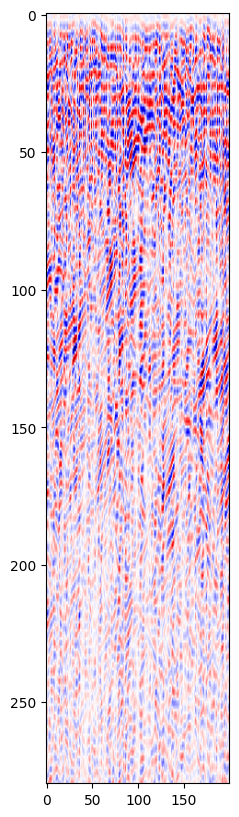

In [9]:
min_x, max_x = 0, 100
min_t, max_t = 0, 700
array, bounds = zoom(p, [min_x, max_x, max_t, min_t])
cmap = plt.get_cmap('seismic')
rgb_img = cmap(array)[:,:,0]
np.save('/Users/coltenrodriguez/Desktop/GPR-modeling/SimulatingGPR/array.npy', array)
plt.imsave('/Users/coltenrodriguez/Desktop/GPR-modeling/SimulatingGPR/array.png', array, cmap='seismic')
fig = plt.figure(figsize=(20,10))
plt.imshow(array, cmap="seismic", aspect=3)
array.shape

## Two runs of manual fitting
An array of tuples of size 3 of the format (apex horizontal position in pixels, apex vertical position in pixels, epsilon)
1. Sparse sampling. Only pick the best, most obvious hyperbolae
2. Dense sampling. Look really hard --> downside: are we immagining a hyperbola when it really isn't one?


In [12]:
points = [(96.21394932641245, 91.73817117718771, 3.1872020277389037),
 (149.19080512199483, 369.71848943317167, 4.907899555727503),
 (307.4408307018802, 122.3275818939788, 3.6698151282688443),
 (283.9298515104694, 352.2602674634739, 5.255000130768836),
 (227.9836089537263, 677.9700427994271, 7.922592317504873),
 (328.23046858290627, 94.102878474549, 3.478741217468942),
 (727.8444096375603, 209.64829063583068, 4.324002261775977),
 (684.232460618321, 28.71286200484331, 3.5497183665294707),
 (624.5684174418653, 670.5868347369592, 7.9256683402988655),
 (971.7456201170642, 56.98216018313612, 3.025878278530732),
 (972.122251898162, 350.1770831319845, 5.133235183458932),
 (1354.0067415528633, 92.66443819337113, 3.791985932870023),
 (1275.1884363123822, 259.96865668628556, 6.3687683416799),
 (1244.9926537866354, 661.7117002860585, 6.896619252804621),
 (1542.8126267197647, 23.291685597646236, 3.1019171069162215),
 (1708.3996735877636, 142.46850398276558, 4.2433382921102325),
 (1498.0110653913334, 571.0033814631065, 4.4562669304473985),
 (2046.7733387670914, 146.14362192130372, 4.281202587245392),
 (1797.8401924432562, 557.346126362376, 6.4123731044143994),
 (2518.9493555669396, 214.34553028079847, 4.676851237153585),
 (2773.249378244265, 513.9931179523248, 5.169562954881795),
 (2673.3336670751023, 499.8173719357162, 5.5624850781136255),
 (2821.393637856055, 72.59710090645213, 2.477577833148144),
 (3411.927721357713, 434.0010991450636, 4.107319494627982),
 (3684.5408365204553, 557.1789713165233, 5.676208365910404),
 (3484.0231965855737, 125.6143874327697, 3.3843664864546845),
 (3519.2516796944687, 35.03555389011689, 2.8073482442105275),
 (4458.408757394646, 285.3816373218993, 4.366778198261907),
 (4715.821951463763, 629.8952560871318, 6.804735106307456),
 (4904.862066198007, 274.10158673701915, 3.447154433442401),
 (5359.861757710611, 228.46838737720657, 3.8610092673353877),
 (6029.834708221511, 112.23058899656536, 3.1028485798092102),
 (6010.460517863255, 250.28853571827895, 3.3655711610908106),
 (5730.907925409929, 654.7662295632847, 7.34100192907199)]

In [11]:
points = [(96.25264000096631, 88.09730933093043, 3.601920446851148),
 (14.282982021063622, 225.6621156733321, 12.617264790746653),
 (96.9984794144397, 77.05081339048611, 3.3138074346164976),
 (9.36377607328773, 199.14155993646565, 6.850902910496019),
 (97.02668912309929, 75.52149062096203, 2.455621851366253),
 (10.93781859454154, 516.5717479086048, 13.433716930138033),
 (67.71462804522766, 343.4835086750948, 9.846193042625393),
 (104.28085111796771, 223.95297669679871, 4.884729138930903),
 (148.99162094342694, 357.03995371411804, 5.269297780086825),
 (95.52372653659805, 520.5589823938056, 9.215775985369836),
 (123.5845493960752, 649.3383815583854, 7.690592986897978),
 (393.40619123372664, 118.22302542129398, 6.6022548721425),
 (306.13887683253995, 111.41332695211194, 4.3497333945461705),
 (236.79631304489573, 227.20793236147423, 7.66791344945864),
 (269.8524802596654, 269.9305580505903, 5.383169015125586),
 (392.8410667526471, 403.39516814574785, 13.247055971595922),
 (266.5504802970628, 515.5534974323087, 7.8014831920868595),
 (346.1274944489204, 550.6469906352, 13.632986974281623),
 (258.58090750827137, 65.89536318345225, 2.7619800192849735),
 (331.67956027961077, 301.80028300099264, 10.060940983671095),
 (435.6557457499814, 124.46193769811255, 3.809476983041193),
 (534.479596320545, 154.89367146324486, 5.224403936579874),
 (483.2983411739034, 339.22139810639817, 7.6099064419357765),
 (501.3545404344769, 660.7425826477989, 17.533368502450895),
 (582.3162773470408, 660.8021864581974, 13.266136905475689),
 (468.1538786279177, 480.20796995179904, 11.819726489302333),
 (549.8711518092008, 418.7088060576368, 13.733178378893438),
 (685.0689241613967, 19.93362383605323, 4.011911541809092),
 (726.5796846960064, 194.3599160045322, 3.3941092179562413),
 (792.0446655542718, 536.4316168261423, 15.600118236578494),
 (676.0955130701161, 230.25696190594556, 4.786653902838898),
 (622.4133129027142, 134.94077445554035, 3.6302828756458507),
 (645.5086572912495, 142.69161709341066, 3.6355596025861963),
 (620.0105334666802, 371.1346901291868, 6.857709239026504),
 (658.8019347319355, 564.2827046435881, 16.63324812773289),
 (684.8025880187232, 23.851038057258105, 4.737488198784883),
 (728.9407483323862, 188.8420516534833, 4.645108443275584),
 (621.6346888762647, 135.12218487599603, 4.485584180515577),
 (645.2100791115597, 139.17242463890832, 5.792992696390306),
 (790.579728056335, 537.6023183901071, 14.951053738977718),
 (626.2765568374439, 613.8835302442246, 16.288074991725807),
 (672.663038093921, 210.6090414491346, 6.0110962462373125),
 (742.6762634392992, 359.74622196605577, 5.813658461929212),
 (973.7013168133712, 344.8089271238523, 7.926414328611979),
 (897.182834659748, 419.3592188399312, 16.189710563879178),
 (879.5048684101961, 84.23679392691255, 3.419201762152601),
 (1107.7541449084936, 197.1917439752604, 8.648421711066067),
 (1047.756523442871, 241.37608649536494, 7.107594677067271),
 (1172.9835065663365, 98.50912150599152, 8.045027316889103),
 (1015.9524576623329, 614.4964755924138, 12.342302431926136),
 (1090.0205435546725, 355.07375820788826, 13.550929470119806),
 (1011.738809227303, 160.07696076197774, 8.632995633282341),
 (1181.5603383175178, 487.79418169492794, 10.609582154050036),
 (1356.0136355098696, 73.81444330136628, 2.212271198053942),
 (1229.239098217751, 220.35329927281256, 6.344531662317339),
 (1214.800517875428, 49.34271733023202, 3.550206664591575),
 (1275.5413527042222, 247.42143922938834, 7.768030352141496),
 (1257.026520363103, 523.3332834570969, 13.559679455040198),
 (1340.3120700829083, 554.0285045218714, 10.445155695603765),
 (1544.2918652530573, 18.859936937633197, 3.0266368502561227),
 (1657.7316966541578, 211.1352345665634, 4.88370800204975),
 (1599.6756276416775, 46.21328330467313, 3.2745426503222657),
 (1604.1840306784845, 346.9230225265849, 9.344257871725425),
 (1428.8187601399675, 497.88440279373907, 6.9242168462127065),
 (1825.650153298214, 50.556580521874615, 2.73543957589768),
 (1882.2347003834361, 233.9931914832619, 5.788287455559036),
 (1917.4236908293408, 574.0722160397552, 16.209323089900344),
 (2101.3662503923765, 517.4706621130317, 16.713566530817722),
 (2084.685410299203, 131.79751802692041, 8.089086201143333),
 (2427.6756621938184, 76.66087650406446, 3.079630102483672),
 (2474.02190102032, 386.21503874895245, 8.74487347814469),
 (2617.6921322938783, 276.5603330766008, 7.034713834956734),
 (2338.43390087658, 124.40655281598512, 4.525159712256573),
 (2626.2182408542353, 448.99385244855137, 7.614117222337622),
 (2791.0709643512932, 391.34124146905054, 7.10053039647647),
 (2927.6707127764334, 263.0578292543951, 4.976362062393765),
 (2705.8865755249144, 103.2369495000351, 5.2580254037827086),
 (3410.5309381096313, 61.88968155031601, 3.4627112560808575),
 (3392.8268826783233, 341.90799266809495, 9.459707425503797),
 (3136.1230359154183, 267.65055766986893, 6.980622133569073),
 (3269.9643050348345, 268.5064076797663, 9.04585022918084),
 (3251.078709547567, 521.2490018116052, 7.421723497793909),
 (3220.6758185588224, 110.91024184403224, 4.832634866223348),
 (3649.6473410204444, 65.60957945203666, 4.548202075665809),
 (3686.663247415746, 561.3223823378094, 13.902826550984038),
 (3484.648421611587, 105.4943928995176, 7.78632989270399),
 (4051.5335312607394, 37.400835372874944, 2.0918716981128984),
 (4146.084478391284, 66.06491875959651, 2.248457861200175),
 (3886.469414281535, 238.7610134442159, 3.54055755555423),
 (4146.323286218734, 283.50645039586084, 7.2870672347780605),
 (4002.9930259926014, 678.8998685261992, 12.293313559852447),
 (4057.2970211836755, 272.700193131395, 8.812516417492395),
 (4500.21294633208, 25.903983872473095, 1.8594589843103593),
 (4499.536425826194, 24.685880324394493, 2.354335932359055),
 (4583.493025716343, 118.25849379149575, 2.5949286815908144),
 (4455.513413698839, 402.31734469083653, 6.658756556851471),
 (4463.403643100625, 650.6140444081965, 10.172464975100098),
 (4323.262487310153, 503.15851104628473, 15.679657411284099),
 (4976.68425753742, 21.12832089799824, 3.1846061111453863),
 (4771.242491720769, 28.18516133002169, 3.4618352407165816),
 (4955.82998100317, 372.3146107594496, 5.734198868601093),
 (4722.843648481252, 320.3568579975993, 6.7901000977702415),
 (4883.471948910884, 582.1199063720157, 6.613252224634112),
 (5611.9617677284305, 247.78906429050608, 6.767511605828111),
 (5320.2054496830515, 635.1635658453235, 9.778520661882926),
 (5389.229318264573, 161.48225983268694, 5.154383046208118),
 (5281.00752807183, 80.07135555627403, 3.03868284140473)]

## Interpolate data points to get velocity model

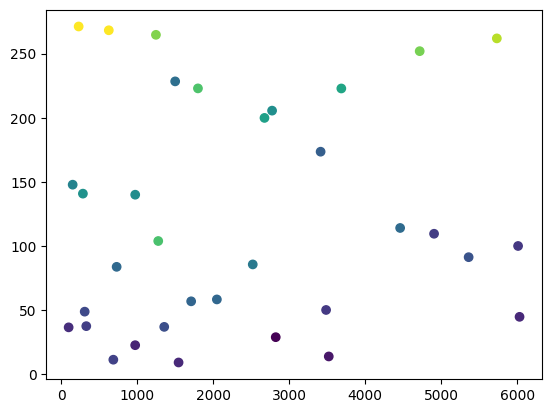

In [13]:
min_x, max_x = 0, 1800
min_t, max_t = 0, 700
array, bounds = zoom(p, [min_x, max_x, max_t, min_t])

# plt.imshow(rg, aspect='auto', cmap='seismic')
def norm(a):
    a = a - np.min(a)
    a/=(np.percentile(a,75)-np.percentile(a,25))
    return a
    
x = []
t = []
perm = []
for point in points:
    x.append(point[0])
    t.append(point[1]/2.5)
    perm.append(point[2])

perm = np.array(perm)
plt.scatter(x, t, c=perm)

(280, 5461)

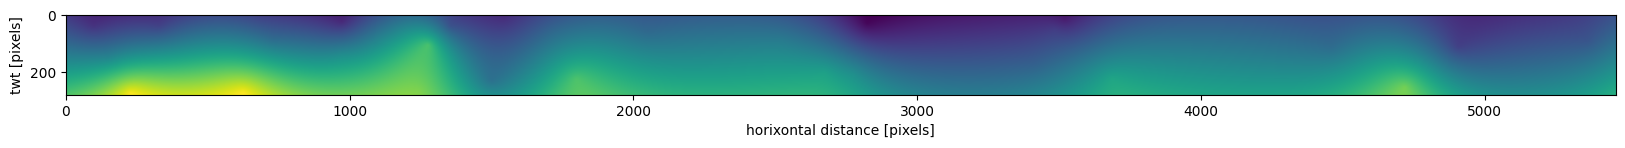

In [24]:
import numpy as np
from scipy.interpolate import griddata
from scipy.interpolate import Rbf

def interpolate_heatmap_rbf(image, xs, ys, values, function="linear"):
    h, w = image.shape
    grid_x, grid_y = np.meshgrid(np.arange(w), np.arange(h))

    rbf = Rbf(xs, ys, values, function=function)
    heatmap = rbf(grid_x, grid_y)

    return heatmap


image = np.zeros_like(array)


xs = x
ys = t
values = perm

heatmap = interpolate_heatmap_rbf(image, xs, ys, values)

# Visualization
fig = plt.figure(figsize=(20,10))
plt.imshow(heatmap)
plt.ylabel('twt [pixels]')
plt.xlabel("horixontal distance [pixels]")
np.save('/Users/coltenrodriguez/Desktop/GPR-modeling/Sections/RoPeR_migration/velocity_model.npy', heatmap)
heatmap.shape


# Method 2: Column Connection Clustering

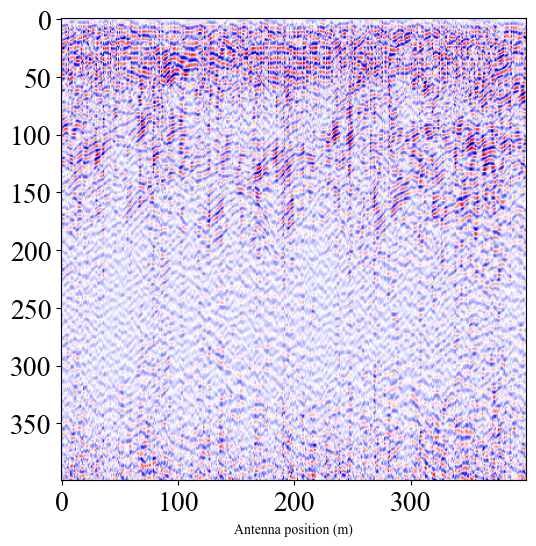

In [621]:
import SimulatingGPR.gprsim as gprsim
import numpy as np
import matplotlib.pyplot as plt
# Parameters
eps_r = 3                  # relative dielectric permittivity
rf = 40e5                 # radar frequency different from pulse frequency
dt = 1e-9                  # seconds
dx = 1                     # meters
region_shape = (70, 1e-6)  # grid (x,z)
SNR = 0.1
wavetype = 'gaussian'

# Point reflectors at (x,t) where x [m] and t [s]
reflectors = [(25, 100e-9), (45, 200e-9)]
long_reflectors = [gprsim.dipping_reflector((0, 50e-9), (40, 50e-9)), gprsim.dipping_reflector((41, 50e-9), (69, 120e-9))]

data, x_positions, t_samples = gprsim.gprsim(eps_r, rf, dt, dx, reflectors, region_shape, wavetype, SNR, long_reflectors)
data = array
plt.style.use('default')
plt.rcParams.update({
    'font.family': 'serif',  # Often a default in MATLAB
    'font.serif': ['Times New Roman'],
    'axes.labelsize': 10,
    'axes.titlesize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'lines.linewidth': 1.5,
    'lines.marker': 'o',  # Example marker, adjust as needed
    'grid.color': 'lightgray',
    'grid.linestyle': ':',
    'grid.linewidth': 0.5,
    'axes.grid': False,
    'figure.subplot.wspace': 0,  # Example: Increase horizontal spacing
    'figure.subplot.hspace': 0.4,  # Example: Increase vertical spacing
    'figure.figsize': (6, 6) # Adjust figure size
})
plt.imshow(data, aspect='auto', cmap='seismic')
plt.xlabel("Antenna position (m)")
plt.show()

## Thresholding

# 5 Migration with three methods

## 5.1 RTM

We need 3 things to image the data with RTM:

1. The wavefield at each timestep. In seismology this corresponds to a 2d array in distance-distance space. In gpr, we just use each trace as our timestep
2. The velocity model: We just did this
3. The source wavelet

### 5.1.1 Characterize the Source wavelet

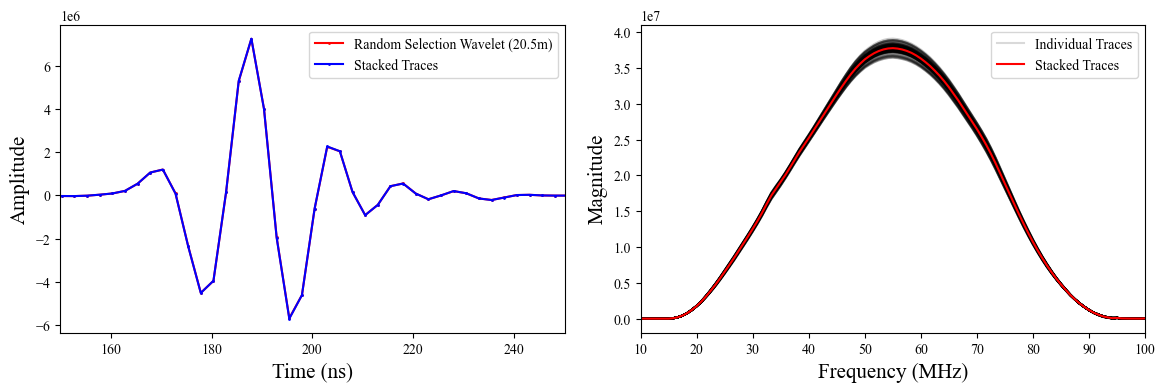

In [52]:
fig, axs = plt.subplots(1, 2)
fig.subplots_adjust(wspace=0.15)
'''
time-space
'''
axs[0].set_ylabel('Amplitude'), axs[0].set_xlabel('Time (ns)'), axs[0].set_xlim(150, 250)
random_wavelet = self_detections[:, 20]
stacked_wavelet = np.mean(self_detections, axis=1)
axs[0].plot(np.linspace(0,1200, self_detections.shape[0]), random_wavelet, label='Random Selection Wavelet (20.5m)', c='red', markersize=1)
axs[0].plot(np.linspace(0,1200, self_detections.shape[0]), stacked_wavelet, label='Stacked Traces', c='blue', markersize=1)
axs[0].legend()


'''
Frequency Space. Taking the FT of each trace and averaging them
'''
freq_space_im = []
for i, trace in enumerate(self_detections.T):
    x = np.array(trace)       # your 1D waveform
    n = len(x)
    
    # Sampling interval (seconds)
    dt = 2.5e-9           # 2.5 ns
    
    # FFT
    X = np.fft.fft(x)
    
    # Frequency axis
    freq = np.fft.fftfreq(n, d=dt)

    # Magnitude spectrum
    magnitude = np.abs(X)
    freq_space_im.append(magnitude)
    
    pos_mask = freq >= 0
    axs[1].plot(freq[pos_mask] * 1e-6, magnitude[pos_mask], color='black', alpha=0.2, markersize=0)

    

magnitude = np.array(freq_space_im).T.mean(axis=1)
pos_mask = freq >= 0
axs[1].plot(freq[pos_mask] * 1e-6, magnitude[pos_mask], color='black', alpha=0.15, markersize=0, label='Individual Traces')
axs[1].plot(freq[pos_mask] * 1e-6, magnitude[pos_mask], color='red', markersize=0, label='Stacked Traces'), axs[1].set_xlim(10, 100)
axs[1].set_xlabel('Frequency (MHz)'), axs[1].set_ylabel('Magnitude')
axs[1].legend()

### 5.1.2 Replicate the Source Wavelet!

In [112]:
import numpy as np

def gaussian_bandlimited_wavelet(
    f0,
    bw_2sigma,
    dt,
    n,
    phase=0.0,
    bw_2sigma_is_fullwidth=False,
    normalize=True
):

    # Frequency grid for real FFT
    f = np.fft.rfftfreq(n, d=dt)

    # Convert "2 sigma" bandwidth into sigma_f
    if bw_2sigma_is_fullwidth:
        # bw_2sigma = 4*sigma_f  => sigma_f = bw_2sigma/4
        sigma_f = bw_2sigma / 4.0
    else:
        # bw_2sigma = 2*sigma_f  => sigma_f = bw_2sigma/2
        sigma_f = bw_2sigma / 2.0

    # Gaussian amplitude spectrum centered at f0
    A = np.exp(-0.5 * ((f - f0) / sigma_f) ** 2)

    # Optional constant phase
    W = A * np.exp(1j * phase)

    # Inverse real FFT -> real time-domain wavelet
    w = np.fft.irfft(W, n=n)

    # Center the wavelet in time (so peak is near t=0)
    w = np.fft.fftshift(w)
    t = (np.arange(n) - n // 2) * dt

    if normalize:
        w /= np.max(np.abs(w)) + 1e-12

    return t, w, f, W

dt = 1e-9          # 1 ns sampling
n  = 90
f0 = 5.5e7          # 55Mhz center frequency
bw_2sigma = 3.5e7   # interpret as 2*sigma_f = 70MHz

t, w, f, W = gaussian_bandlimited_wavelet(f0, bw_2sigma, dt, n)
plt.plot(t, w)

### 5.1.2 We're kind of just getting RTM grocery list right now: Display the velocity model

In [119]:
from bruges.filters.wavelets import ricker
import SimulatingGPR.migration as mig
c0 = 3e8
f0 = 5.5e7

radargram = array
eps = heatmap[:, :200]
velocity = c0 / np.sqrt(eps.T)

w, _ = ricker(duration=1.5 / f0, dt=1e-9, f=f0)
w /= np.max(np.abs(w))

migrated_image = mig.gpr_rtm(
    radargram=radargram,
    shot_positions=np.linspace(0,100,200),
    velocity_model=velocity,
    dx=0.5,
    dz=0.5,
    dt=2.5e-9,
    source_wavelet=w
    )
migrated_image = np.clip(migrated_image.T, a_min=-np.max(np.abs(migrated_image))*0.02, a_max=np.max(np.abs(migrated_image))*0.02)


IndexError: index 200 is out of bounds for axis 0 with size 200

In [123]:
radargram.shape

(280, 200)